В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import roc_curve, auc, confusion_matrix, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

In [74]:
raw_df = pd.read_csv('train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df.Exited)

In [75]:
raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


Area under ROC score on Training dataset: 0.88242


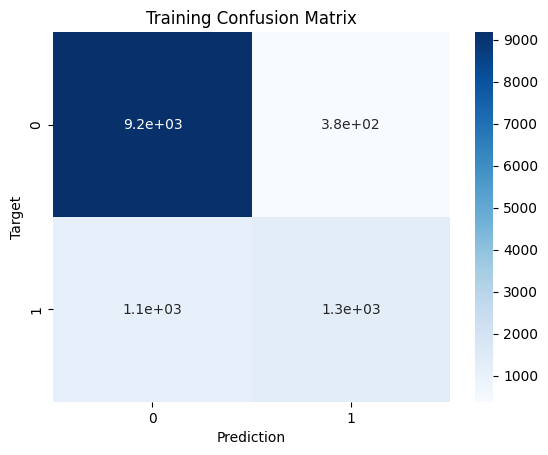

Area under ROC score on Validation dataset: 0.87971


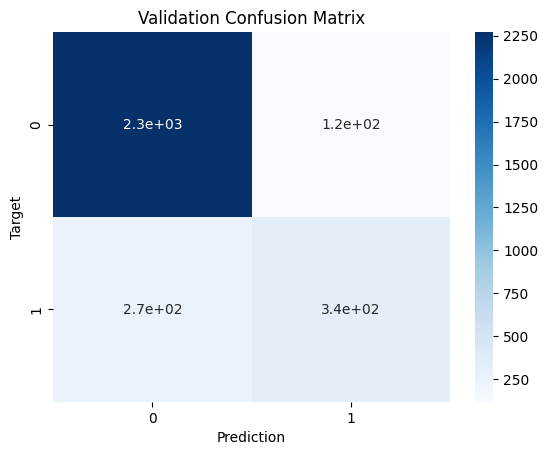

['bank_customer_behavior.joblib']

In [76]:
raw_df = pd.read_csv('train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df.Exited)

# Створюємо трен. і вал. набори
input_cols = list(raw_df.columns)[2:-1]
target_col = list(raw_df.columns)[-1:]
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes('number').columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)
    fpr, tpr, thresholds = roc_curve(targets, probs[:,1])
    roc_auc = auc(fpr, tpr)

    print(f"Area under ROC score on {name} dataset: {roc_auc:.5f}")
    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'bank_customer_behavior.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Training dataset: 0.92165


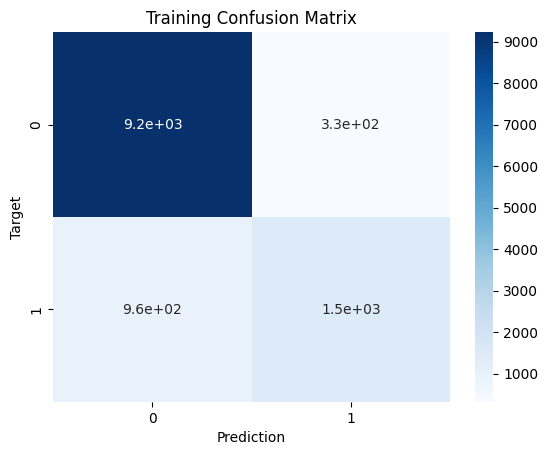

Area under ROC score on Validation dataset: 0.91873


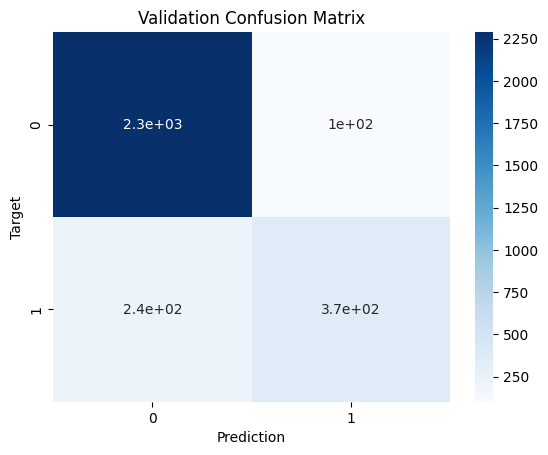

In [77]:
# transformer for scaling and adding polynomial features (2nd degree)
numeric_poly_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly_features', PolynomialFeatures(degree=2))
])

# include numeric+poly and categorical transformers into preprocessing
poly_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numeric_poly_transformer, numeric_cols)
    ])

# pipeline for preprocessing and fitting the model
poly_model_pipeline = Pipeline(steps=[
    ('poly_preprocessor', poly_preprocessor),
    ('classifier', LogisticRegression())
])

# preprocess data and fit model
poly_model_pipeline.fit(train_inputs, train_targets)

# evaluate model performance
train_preds_poly = predict_and_plot(poly_model_pipeline, train_inputs, train_targets, 'Training')
val_preds_poly = predict_and_plot(poly_model_pipeline, val_inputs, val_targets, 'Validation')

**Висновок**

Модель покращилась з додаванням поліноміальних ознак. AUROC на тренувальних та валідаційних даних: 0.92165 та 0.91873 відповідно. Ці значення є достатньо високими і різняться мінімально, то робимо висновок, що underfit чи overfit не спостерігається і модель достатньо добре генералізує наші дані.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Training dataset: 0.93287


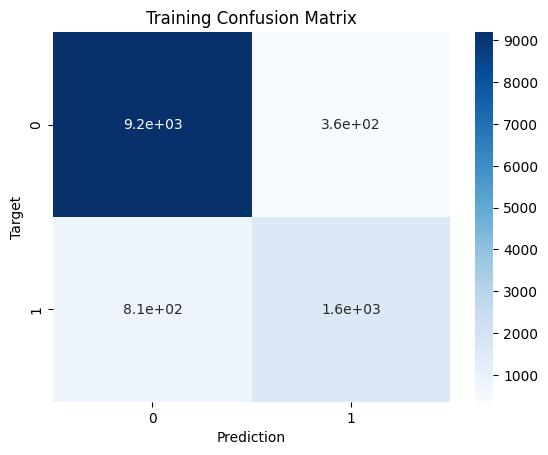

Area under ROC score on Validation dataset: 0.92987


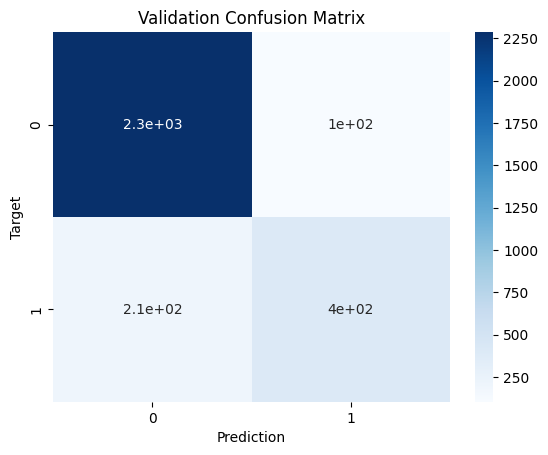

In [78]:
# transformer for scaling and adding polynomial features (2nd degree)
numeric_poly4_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly_features', PolynomialFeatures(degree=4))
])
# include numeric+poly and categorical transformers into preprocessing
poly4_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numeric_poly4_transformer, numeric_cols)
    ])

# pipeline for preprocessing and fitting the model
poly4_model_pipeline = Pipeline(steps=[
    ('poly_preprocessor', poly4_preprocessor),
    ('classifier', LogisticRegression())
])

# preprocess data and fit model
poly4_model_pipeline.fit(train_inputs, train_targets)

# evaluate model performance
train_preds_poly4 = predict_and_plot(poly4_model_pipeline, train_inputs, train_targets, 'Training')
val_preds_poly4 = predict_and_plot(poly4_model_pipeline, val_inputs, val_targets, 'Validation')

**Висновок** Додавання поліноміальниз ознак до 4 степеня покращило роботу моделі. З невеликої різниці між AUROC для тренувального та валідаційного наборів робимо висновок, що модель не має проблеми з перенавчанням чи недонавчанням і здатна суттєво узагальнювати дані.

In [79]:
# prepare submission file for kaggle competition
# load and select data
test_raw_df = pd.read_csv('test.csv')
test_inputs = test_raw_df[input_cols].copy()
test_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [80]:
# make predictions using polynomial model (4th degree) and derive probabilities
test_preds = poly4_model_pipeline.predict(test_inputs)
test_probs = poly4_model_pipeline.predict_proba(test_inputs)[:,1]

In [81]:
test_probs[0:10]

array([0.07536838, 0.02025209, 0.07011591, 0.40433555, 0.02480382,
       0.13855378, 0.03620919, 0.07566257, 0.01667888, 0.01385934])

In [82]:
# add new column (Exited) with predicted probabilities of observation to refer to class 1
test_raw_df['Exited'] = np.round(test_probs,2)
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.08
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.02
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.07
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.40
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.02


In [83]:
# read from file
sample_submission_data = pd.read_csv('sample_submission.csv')
sample_submission_data.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [84]:
# add data into submission file (according to id)
sample_submission_data['Exited'] = sample_submission_data['id'].map(
    test_raw_df.set_index('id')['Exited']
)
sample_submission_data.head()

,id,Exited
0,15000,0.08
1,15001,0.02
2,15002,0.07
3,15003,0.40
4,15004,0.02


In [85]:
sample_submission_data.to_csv('sample_submission.csv', index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [86]:
# load data
regression_raw = pd.read_csv('regression_data.csv')
regression_num_cols = list(regression_raw.columns)[:-1]
regression_raw.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [87]:
regression_num_cols

['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']

In [88]:
# split to train and test
regression_train, regression_test = train_test_split(regression_raw, test_size=0.2, random_state=42)

In [89]:
regression_train.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
70,0.791663,0.628346,0.624120,-1.214189,1.158111,-59.539425
78,0.311250,1.119575,3.078881,-0.249036,0.576557,-11.069842
47,0.871125,1.201214,-0.326024,0.289775,2.075401,14.106593
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
12,-0.653329,0.404982,1.765454,-0.334501,-0.474945,-15.024066


In [90]:
# setup scaler and scale data
std_scaler = StandardScaler()
std_scaler.fit(regression_train[regression_num_cols])
regression_train[regression_num_cols] = std_scaler.transform(regression_train[regression_num_cols])
regression_test[regression_num_cols] = std_scaler.transform(regression_test[regression_num_cols])

In [91]:
regression_train.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
70,0.891659,0.521174,0.520348,-1.228460,1.099903,-59.539425
78,0.369802,0.969049,3.065161,-0.136425,0.520280,-11.069842
47,0.977976,1.043483,-0.464651,0.473221,2.014147,14.106593
0,-0.175059,-1.312472,-1.034407,0.755108,-1.088165,28.938854
12,-0.677992,0.317524,1.703552,-0.233125,-0.527731,-15.024066


In [92]:
# setup and train model
poly5_features = PolynomialFeatures(degree=5)

In [93]:
# add polynomial features
regression_train_poly = poly5_features.fit_transform(regression_train[regression_num_cols])
regression_test_poly = poly5_features.transform(regression_test[regression_num_cols])

In [94]:
# setup and train linear regression model to forecast target (float)
linreg_model = LinearRegression()
linreg_model.fit(regression_train_poly, regression_train['target'])

LinearRegression()

In [95]:
# make prediction for data in train and test sets
predict_regression_train_poly = linreg_model.predict(regression_train_poly)
predict_regression_test_poly = linreg_model.predict(regression_test_poly)

In [96]:
# evaluate model
rmse_regression_train_poly = np.sqrt(mean_squared_error(regression_train['target'], predict_regression_train_poly))
rmse_regression_test_poly = np.sqrt(mean_squared_error(regression_test['target'], predict_regression_test_poly))

print(f"RMSE for Train (Linear Regression): {rmse_regression_train_poly:.4f}")
print(f"RMSE for Test (Linear Regression): {rmse_regression_test_poly:.4f}")

RMSE for Train (Linear Regression): 0.0000
RMSE for Test (Linear Regression): 35.6281


In [97]:
regression_train['target'].mean(), regression_train['target'].std()

(np.float64(-6.450753928428644), 44.35003659161175)

**Висновок** У даному випадку модель демонструє перенавчання, так як на тренувальних даних її прогноз повністю збігається з наявними значеннями цільової змінної і RMSE  дорівнює 0, а на тестових даних модель має помірну похибку.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [98]:
# array of models to test
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet(),
]

In [99]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_metrics = np.sqrt(mean_squared_error(y_train, y_train_pred)).round(6)
    val_metrics = np.sqrt(mean_squared_error(y_val, y_val_pred)).round(6)

    return dict(train=train_metrics, val=val_metrics)

In [100]:
# add polynomial features (degree=20)
poly20_features = PolynomialFeatures(degree=20)

regression_train_poly20 = poly20_features.fit_transform(regression_train[regression_num_cols])
regression_test_poly20 = poly20_features.transform(regression_test[regression_num_cols])

regression_train_poly20.shape, regression_test_poly20.shape

((103, 53130), (26, 53130))

In [101]:
# test all models
import warnings

warnings.filterwarnings("ignore")

for model in models:
    model.fit(regression_train_poly20, regression_train.target)
    rmse  = evaluate_model(model, regression_train_poly20, regression_train.target, regression_test_poly20, regression_test.target)
    print(f'{str(model)}: {rmse}')

LinearRegression(): {'train': np.float64(1.008117), 'val': np.float64(31605765.905021)}
Ridge(): {'train': np.float64(30.870077), 'val': np.float64(152443.043004)}
Lasso(): {'train': np.float64(2.19752), 'val': np.float64(14.944979)}
ElasticNet(): {'train': np.float64(9.147658), 'val': np.float64(241.663856)}


In [102]:
# collect coefficients
model = Lasso()
model.fit(regression_train_poly20, regression_train.target)

coefs_df = pd.DataFrame(poly20_features.get_feature_names_out(regression_train[regression_num_cols].columns), columns=['feature_name'])
coefs_df['value'] = model.coef_.round(5).flatten()

In [103]:
# coefficient analysis
coefs_df[coefs_df.value > 0.001]

,feature_name,value
4,feature_4,38.94995
246,feature_4^5,0.63878
674,feature_2^6 feature_4,0.00828
756,feature_3^7,0.00324
784,feature_4^7,0.00117
2000,feature_4 feature_5^8,0.02740
3500,feature_1^2 feature_2^8 feature_4,0.00116
3663,feature_1^2 feature_3^9,0.00267
3974,feature_1 feature_3^2 feature_4^8,0.00110
3983,feature_1 feature_3 feature_4^9,0.00423


In [104]:
coefs_df.value[coefs_df.value > 0.001].count()

np.int64(32)

**Висновок**
Майже усі розглянуті моделі демонструють перенавчання. Серед іншого, це обумовлено також великою кількістю доданих поліноміальних ознак (поліном 20-го степеня). Як наслідок, тренувальний і тестовий набори мають 53130 ознак, що неспіврозмірно багато для даної кількості спостережень (рядків) - 103 і 26  відповідно. У даному експерименті найкращу здатність генералізувати дані демонструє модель Lasso. Подальший аналіз коефіцієнтів виявив, що модель використовує тільки малу частину всіх характеристик (features), так як коефіцієнти решти характеристик дуже близькі до 0 і, відповідно, такі характеристики нівелюються моделлю. Наприклад, тільки 32 коефіцієнти з 53130 є вищими за 0.001 і тільки 3 коефіцієнти з 53130 є вищими за 0.01.